# A/B Testing: Does Showing Users an Advertisement Instead of a Public Service Announcement Increase Conversion?

## <u>Business Context and Project Structure</u>

The objective of this analysis is to determine whether showing users an advertisement (`ad`) as opposed to a public service announcement (`psa`) leads to a statistically significant increase in product conversion. 

Users were divided into two different groups:
- **Control (`psa`)** – public service announcement
- **Treatment (`ad`)** – advertisement

The primary metric that we will be investigating is the `conversion rate`, which is measured by the binary variable `converted` and tells us whether the user made a purchase after being exposed to either the control or treatment condition. 

This analysis will: 
- Assess the quality of the dataset
- Compare the rate of conversion between the two groups
- Test whether the difference in conversion is statistically significant using a `two-proportion z-test`
- Calculate the confidence intervals and effect size
- Explore the number of ads, the day that most ads were viewed and the hour that most ads were viewed as secondary variables (Measured by the variables `total ads`, `most ads day` and `most ads hour`)
- Provide a recommendation based on the results
- Document any relevant assumptions and limitations

## <u>Data Loading and Understanding</u>

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

In [19]:
df= pd.read_csv('marketing_AB.csv')
df.head()



,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [20]:
print("df info:")
print(df.info())
print("df describe:")
print(df.describe())
print("df shape:")
print(df.shape)
print("df null count:")
print(df.isna().sum())
print("df duplicate count:")
print(df.duplicated().sum())


df info:
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB
None
df describe:
          Unnamed: 0       user id      total ads  most ads hour
count  588101.000000  5.881010e+05  588101.000000  588101.000000
mean   294050.000000  1.310692e+06      24.820876      14.469061
std    169770.279668  2.022260e+05      43.715181       4.834634
min         0.000000  9.000000e+05       1.000000       0.000000
25%    147025.000000  1.143190e+06       4.000000      11.000000
50%    294050.000000  1.313725e+06      1

The column `Unnamed: 0` are just indexes, so they can be safely removed.

In [21]:
df = df.drop(columns='Unnamed: 0')
df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='str')

The dataset contains **588,101** unique observations and 6 variables after removing the exported dataframe index. 

There are no missing values or duplicated rows and the `user id` variable is unique for every observation. The variables also contain values within their expected ranges. `Test group` contains the experimental groups, `converted` is a binary variable of True or False, and `most ads hour` is a numerical variable spanning from 00-23, with each value representing the hour of the day that each user viewed the most ads. 

The `total ads` variable is **extremely** right skewed, having a median of `13` and a max value of `2065`. These extreme values will be investigated during the EDA instead of being removed blindly at this stage. 

The variables `most ads day` and `most ads hour` will be treated as categorical/time-based variables as opposed to numerical measurements, as they represent when users viewed the most advertisements. 


## <u>EDA</u>

#### Treatment vs Control Sample Sizes

test group
ad     564577
psa     23524
Name: count, dtype: int64


Text(0, 0.5, 'Count')

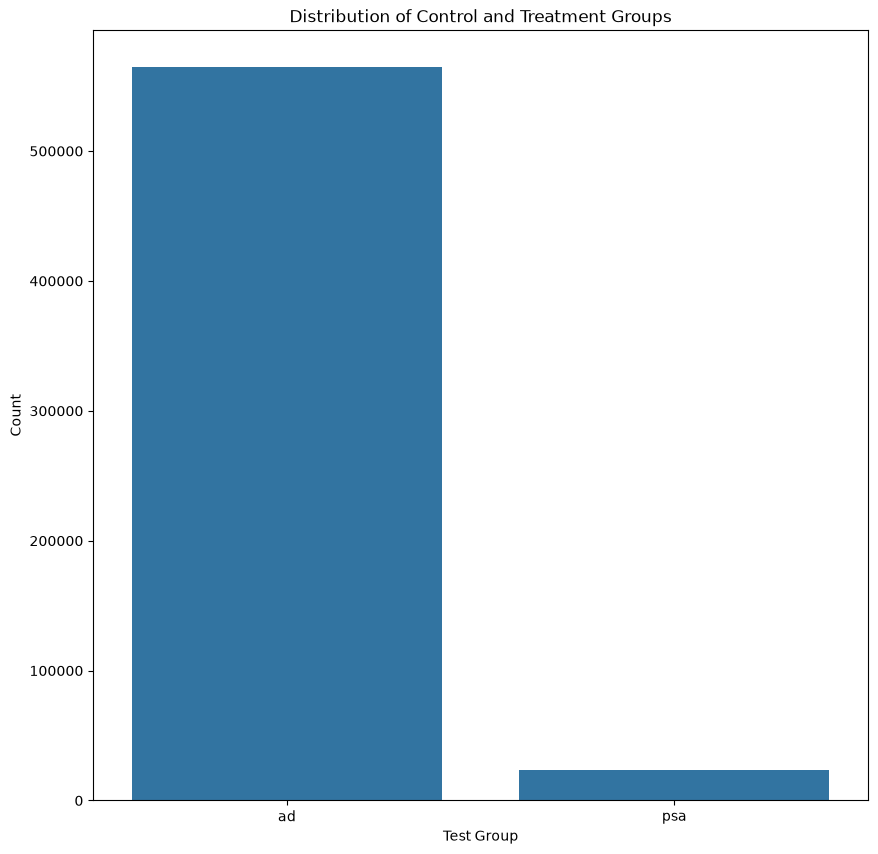

In [22]:
group_counts = df['test group'].value_counts()
plt.figure(figsize=(10, 10))
sns.barplot(x = group_counts.index, y = group_counts.values)
print(group_counts)
plt.title("Distribution of Control and Treatment Groups")
plt.xlabel("Test Group")
plt.ylabel("Count")


The treatment and control groups are highly imbalanced, with `~96%` being assigned to the treatment group (ad) and `~4%` of users to the control group (psa). The dataset does not provide any information regarding how the treatment and control groups were allocated, so the reasoning behind this imbalance cannot be determined without making assumptions. However, the control group does still contain 23524 observations, which is substantial enough for statistical analysis and hypothesis testing. 

#### Overall Conversion

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


Text(0.5, 1.0, 'Conversion Rate of Control and Treatment Groups')

<Figure size 640x480 with 0 Axes>

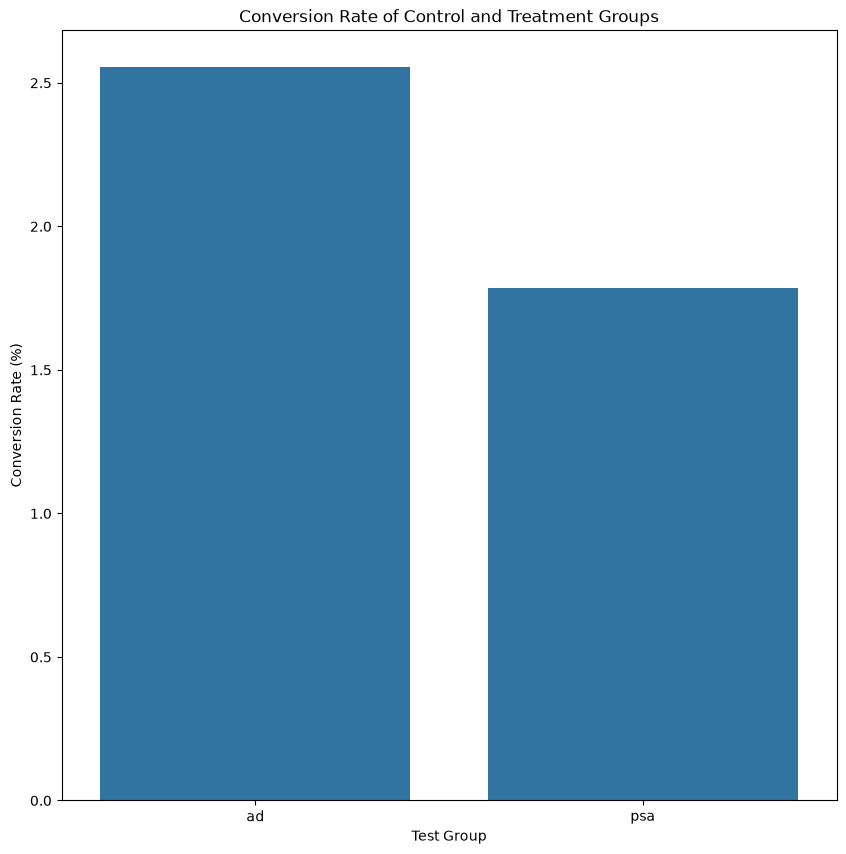

In [23]:
conversion_rates = df.groupby('test group')['converted'].mean()*100
print(conversion_rates)

plt.clf()
plt.figure(figsize=(10, 10))
sns.barplot(x= conversion_rates.index, y = conversion_rates.values)
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate of Control and Treatment Groups")

The treatment group (`ad`) had a conversion rate of `~2.55%` compared to `~1.79%` for the control group(`psa`), suggesting that those who viewed the advertisement as opposed to the public service announcement were more likely to make a purchase. With this said however, hypothesis testing is required to understand whether this is statistically significant or a result of random variation. 

### Distribution of Total Ads

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64


<Figure size 640x480 with 0 Axes>

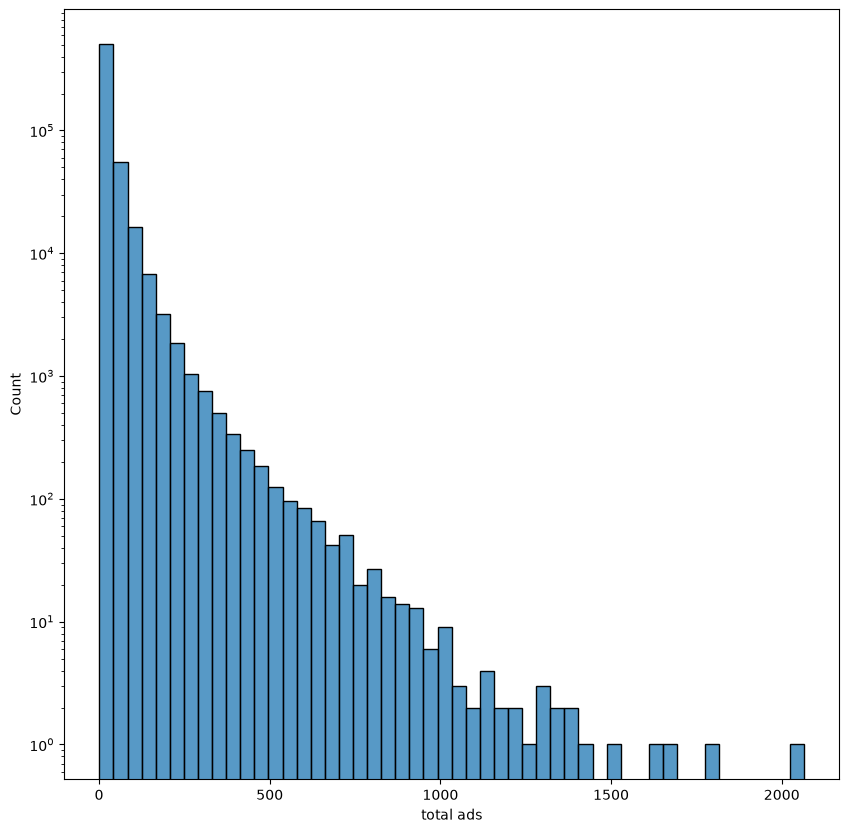

In [24]:
print(df['total ads'].describe())
plt.clf()
plt.figure(figsize=(10, 10))
sns.histplot(data = df, x = 'total ads', bins=50)
plt.yscale('log')
plt.show()

The distribution of `total ads` is extremely right skewed, with the vast majority of users viewing relatively few advertisements compare to the outliers. Roughly `85.2%` of users viewed between 1-42 ads, and approximately 94.6% viewed less than `84 ads`. There is an extreme right tail extending to `2065 advertisements`, with only a small number of users exposed to a exceptionally large number of ads. There is no evidence in the dataset that these are invalid entries, so they have been retained for analysis. 

Given this distribution, it'd be interesting to see if there is a correlation between the number of ads viewed and the conversion rate. This could indicate that a higher exposure to the ad is associated with a higher rate of conversion. I will leave this until I analyse the secondary variables.

### Total Ads By Conversion Status

              count       mean        std  min   25%   50%    75%     max
converted                                                                
False      573258.0  23.291495  40.863176  1.0   4.0  13.0   26.0  2065.0
True        14843.0  83.887759  87.455498  1.0  35.0  64.0  103.0  1778.0


<Figure size 640x480 with 0 Axes>

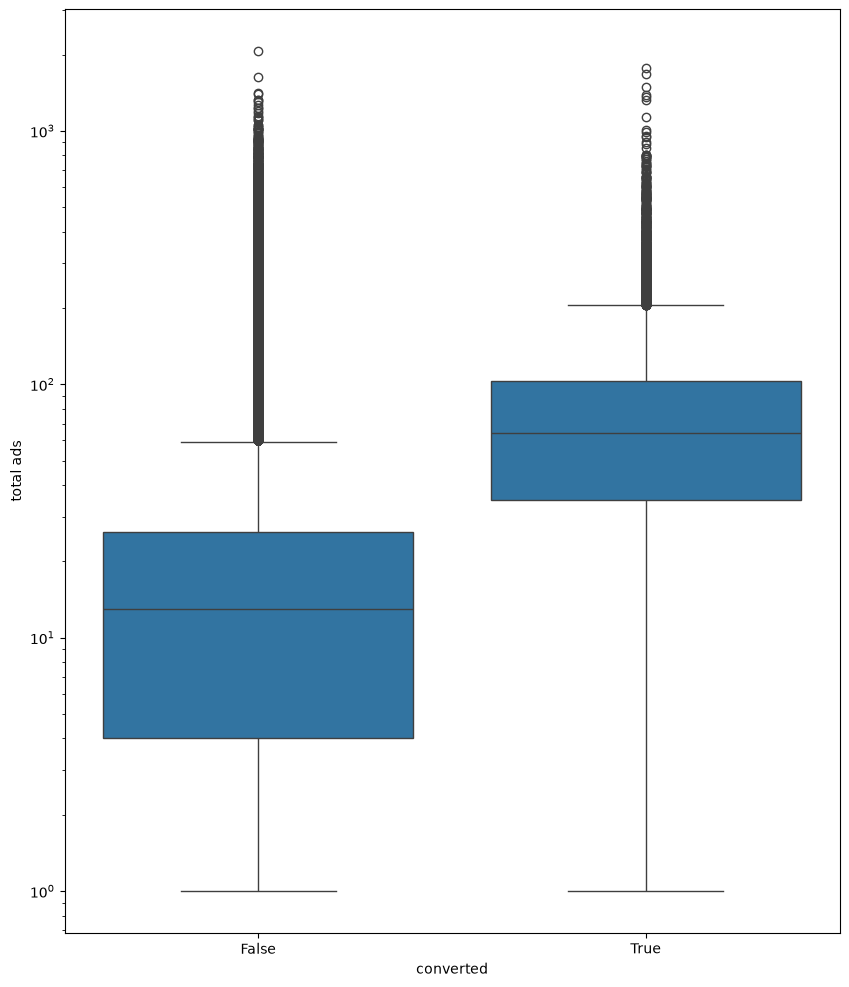

In [25]:
print(df.groupby('converted')['total ads'].describe())
plt.clf()
plt.figure(figsize=(10, 12))
sns.boxplot(data=df, x = 'converted', y = 'total ads')
plt.yscale('log')

The users who converted had a significantly higher exposure to advertisements than those who did not. For converted users, the median number of advertisements viewed was `64` compare to only `13` for those who did not convert. The upper quartile is also notably larger for those who did convert with a value of `103` compared to only `26` for those who did not convert. 

The box plots paint a clear positive association between the number of advertisements viewed and conversion rate, though it's important to note that this is an observational relationship and does not alone establish causation. 

## <u>Statistical Analysis (z-test of proportions)</u>

In the EDA we discovered that there is a higher conversion rate for the treatment group (viewed the ad) than the control group (public service announcement). To determine whether this observation has statistical significance, a z-test will be conducted using a significance level of `0.05`. The `null hypothesis` will be that there is no statistical difference in conversion rates between the two groups, while the `alternative hypothesis` is that the two groups differ in conversion rates. \
A `z-test` is appropriate because the outcome variable is binary and the analysis compares the proportion of conversions between two independent groups, which in this case are the control group (`psa`) and the treatment group (`ad`).\
The large sample sizes of both independent groups also satisfies the conditions for normal approximation that are required for a reliable z-test. 



### z-test

Before conducting the test, the data first needs to be reduced to the number of observations for each group and the size of each group, which will be stored in the variables `nobs` (number of observations) and `count` (number of conversions). 

The `nobs` provide the denominator for each conversion rate, while the `count` provides the numerator, allowing us to get the proportions. These values are stored as arrays so they can be passed into the `proportions_ztest()` function. 

In [26]:
group_sizes = df['test group'].value_counts()
conversions = df.groupby('test group')['converted'].sum()

print("The group sizes are: \n{}".format(group_sizes))
print("The number of conversions are: \n{}".format(conversions))


count = np.array([conversions['ad'], conversions['psa']])
nobs = np.array([group_sizes['ad'], group_sizes['psa']])

The group sizes are: 
test group
ad     564577
psa     23524
Name: count, dtype: int64
The number of conversions are: 
test group
ad     14423
psa      420
Name: converted, dtype: int64


In [27]:
z_stat, p_value = proportions_ztest(count, nobs)
print("The z_stat is : \n{}".format(z_stat))
print("The p_value is: \n{}".format(p_value))

The z_stat is : 
7.3700781265454145
The p_value is: 
1.7052807161559714e-13


### Interpreting the Results

The test gave a `z-statistic` of `7.37` and a `p_value` of `1.705x10⁻¹³`. The `p_value` is significantly lower than than the threshold of `0.05`, indicating that the difference in conversion rates between `ads` and `psa` is statistically significant. Therefore, I reject the null hypothesis that there is not a difference in conversion rates between the treatment and control groups, as the results of the `z-test` provide strong statistical evidence that the difference in conversion rates between the two groups is unlikely to be explained by random variation alone. \
The positive `z-statistic` also indicates that the conversion is rate is higher for the treatment group than the control group.

Although the hypothesis test tells us that the difference between the treatment and control group is statistically significant, it does not tell us the precision at which the conversion rate has been calculated, so I will now calculate a `95% confidence interval` for the conversion rate of each group. These intervals will provide a range of plausible conversion rates for both the control and treatment group and allow us to assess the uncertainty around the estimates. 

In [28]:
ad_rate = conversions['ad']/group_sizes['ad']
psa_rate = conversions['psa']/group_sizes['psa']
difference = ad_rate - psa_rate

print("ad conversion rate is {} \npsa conversion rate is {} \ndifference is {}".format(ad_rate, psa_rate, difference))

ad conversion rate is 0.025546559636683747 
psa conversion rate is 0.01785410644448223 
difference is 0.007692453192201517


In [29]:
ad_ci = proportion_confint(count = conversions['ad'], nobs= group_sizes['ad'], alpha = 0.05)
psa_ci = proportion_confint(count = conversions['psa'], nobs = group_sizes['psa'], alpha = 0.05)

#convert to percentages
ad_ci_pct = np.array(ad_ci) * 100
psa_ci_pct = np.array(psa_ci) * 100
print("ad 95% CI: \n{} \npsa 95% CI: \n{}".format(ad_ci_pct, psa_ci_pct))

ad 95% CI: 
[2.51349995 2.59581197] 
psa 95% CI: 
[1.61619147 1.95462982]


The estimated conversion rate for the `treatment group` is `2.55%`, with a 95% confidence interval of `~2.51%-~2.6%`. In contrast, the estimated conversion rate for the `control group` is `~1.79%` with a 95% confidence interval of `~1.62%-~1.95%`. \
This gives us an estimate of the uncertainty around each group's conversion rate, with the figures further supporting a statistical difference as there is no overlap within the confidence intervals of each group.

The individual confidence intervals show the uncertainty around the estimated rate of conversion for each group, but what is more useful for comparing the groups is the uncertainty around the difference between the control and treatment groups itself. I will therefore calculate a 95% confidence interval for the difference in conversion rates. This will provide a range of plausible values for the difference between the treatment and control groups. 

To begin, I first calculate the standard error of the difference to approximate the uncertainty between conversion rates of the two groups. I then use this standard error to create a `95% confidence interval` around the difference, using a `critical value of 1.96` for a 95% confidence interval. The resulting intervals will show the upper and lower bounds of the plausible values for the difference in conversion rates between the treatment and control groups. 

In [30]:
se_difference = np.sqrt(ad_rate * (1 - ad_rate) / group_sizes['ad'] + psa_rate * (1 - psa_rate) / group_sizes['psa'])

ci_lower = difference - 1.96 * se_difference
ci_upper = difference + 1.96 * se_difference

print("95% CI for difference:")
print(ci_lower, ci_upper)

print("95% CI as pct:")
print(ci_lower * 100, ci_upper * 100)

95% CI for difference:
0.00595090043017032 0.009434005954232714
95% CI as pct:
0.5950900430170319 0.9434005954232714


The observed difference in conversion between the treatment and control groups is `~0.77%`. the results show that the 95% confidence interval for this gives a range between `0.6%` and `~0.94%`. \
As the entire results are above 0, this provides further evidence that there is statistical significance of the treatment group (ads) having a higher conversion rate than the control group (psa).

While the difference in conversion rates between the two groups is useful, it does not clearly the size of improvement in relation to the control group. I will therefore calculate the `relative lift`, which measures the increase in conversion rate for the treatment group relative to the control group.

In [31]:
relative_lift = difference/psa_rate
print("The relative lift is: \n{}".format(relative_lift))
relative_lift_pct = relative_lift * 100
print("The advertisement increased conversion rate by: \n{}".format(relative_lift_pct))

The relative lift is: 
0.43085064022225833
The advertisement increased conversion rate by: 
43.085064022225836


The results show a relative lift of `~43.1%`, meaning that the conversion rate for those shown the advertisement was roughly 43% higher than those who viewed the public service announcement. 

## <u>Secondary Analysis</u>

The statistical analysis identified that there is statistical evidence of the advertisements increasing conversions when compared with the public service announcement. I will follow with some secondary analysis, in which I aim to explore associations between other variables in the dataset and conversions.

The aim is not to establish more causal relationships, but to instead find patterns that add additional context to the A/B test. I will examine whether there is a relationship between `conversion rate and the number of ads viewed`, `conversion rate and the day that most ads are viewed`, and finally `conversion rate and the time of day that most ads are viewed`. 

### Conversion Rate by Number of Ads Viewed

The first secondary analysis will investigate whether conversion rate varies based on the number of ads viewed. During the prior EDA, it was found that those who converted has a substantially higher median number of ads viewed than those who did not, so it will be useful to investigate this relationship in more detail. \
I will create bins of users by the number of ads that they viewed, then calculate the conversion rate of each binned group. These results will then be plotted in a barchart, allowing me to visualise any association between the conversion rate and number of ads viewed. 

ads_group
0-10       0.329019
10-20      0.839321
20-40      2.308729
40-80      8.318301
80-160    16.682252
160+      15.792832
Name: converted, dtype: float64


Text(0.5, 1.0, 'Conversion Rate by Number of Ads viewed')

<Figure size 640x480 with 0 Axes>

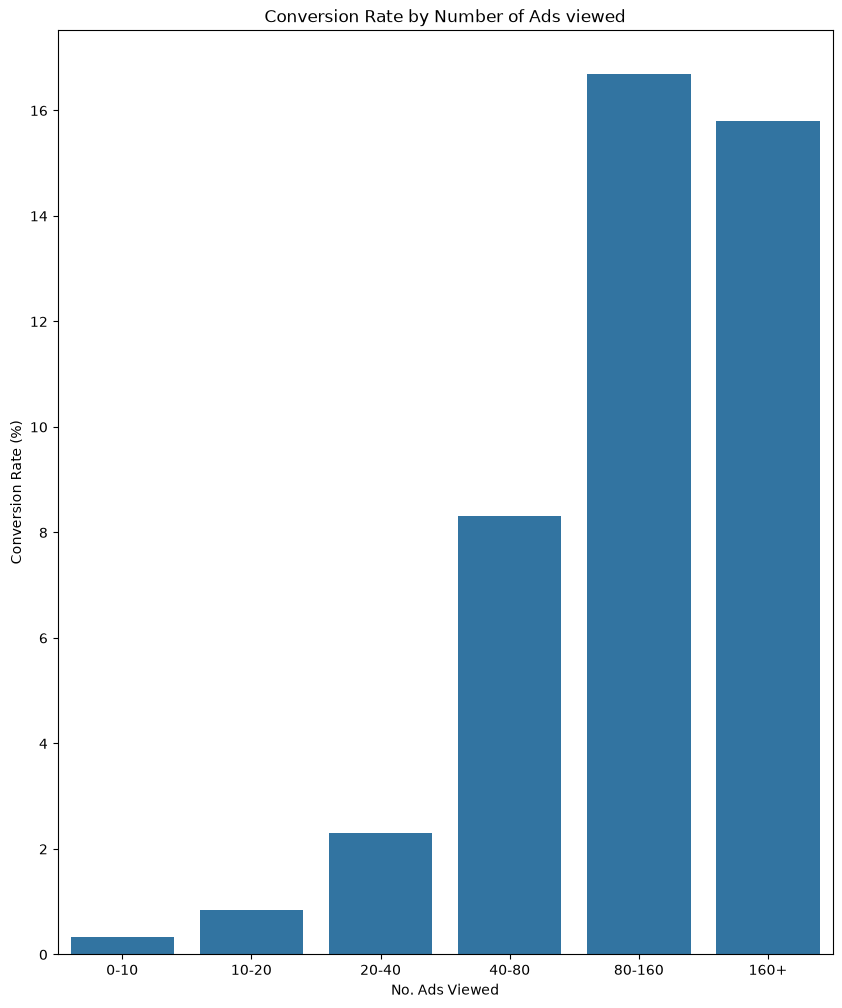

In [36]:
bins = [0, 10, 20, 40, 80, 160, np.inf]
labels = ['0-10', '10-20', '20-40', '40-80', '80-160', '160+']
df['ads_group'] = pd.cut(df['total ads'], bins = bins, labels = labels)

conversion_by_ads_group = df.groupby('ads_group', observed = True)['converted'].mean()*100
print(conversion_by_ads_group)

plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = conversion_by_ads_group.index, y = conversion_by_ads_group.values)
plt.ylabel("Conversion Rate (%)")
plt.xlabel("No. Ads Viewed")
plt.title("Conversion Rate by Number of Ads viewed")


The results show a clear positive association between the number of ads viewed and the conversion rate. Those who saw `0-10 ads` had a conversion rate of `~0.33%` and `10-20 ads` a conversion rate of ``0.84%`. This upwards trend continues to a conversion rate of `~16.68%` for those who viewed `80-160 ads`. The `160+` group showed a slight decrease to a conversion rate of `~15.79%`, though this rate is still substantially higher than those who viewed significantly less ads. 

This suggests that those who view more ads are much more likely to convert. It's important to note however that this relationship is observational and doesn't show a causal relationship. There are potential confounding variables such as those who are already engaged with the brand may be more likely to view the ads, or be more likely to make a purchase in the first place. Therefore, this analysis lends useful context to the prior A/B test but does not alone provide causal evidence that an increased exposure to advertisements leads to a higher rate of conversion. 

### Conversion Rate By Day

Next I will investigate whether there is an association between the day of the week that users viewed the most advertisements and the conversion rate for that day. This could identify whether there are any differences in user behaviour across the week and can give context to when advertisements are the most effective. 

I will again calculate the conversion rate for each day of the week and plot the results using a barchart. The days will be ordered chronologically to make any differences easier to identify. 

most ads day
Monday       3.281155
Tuesday      2.984034
Wednesday    2.494191
Thursday     2.157094
Friday       2.221190
Saturday     2.105070
Sunday       2.447565
Name: converted, dtype: float64


Text(0.5, 1.0, 'Conversion Rate by Day')

<Figure size 640x480 with 0 Axes>

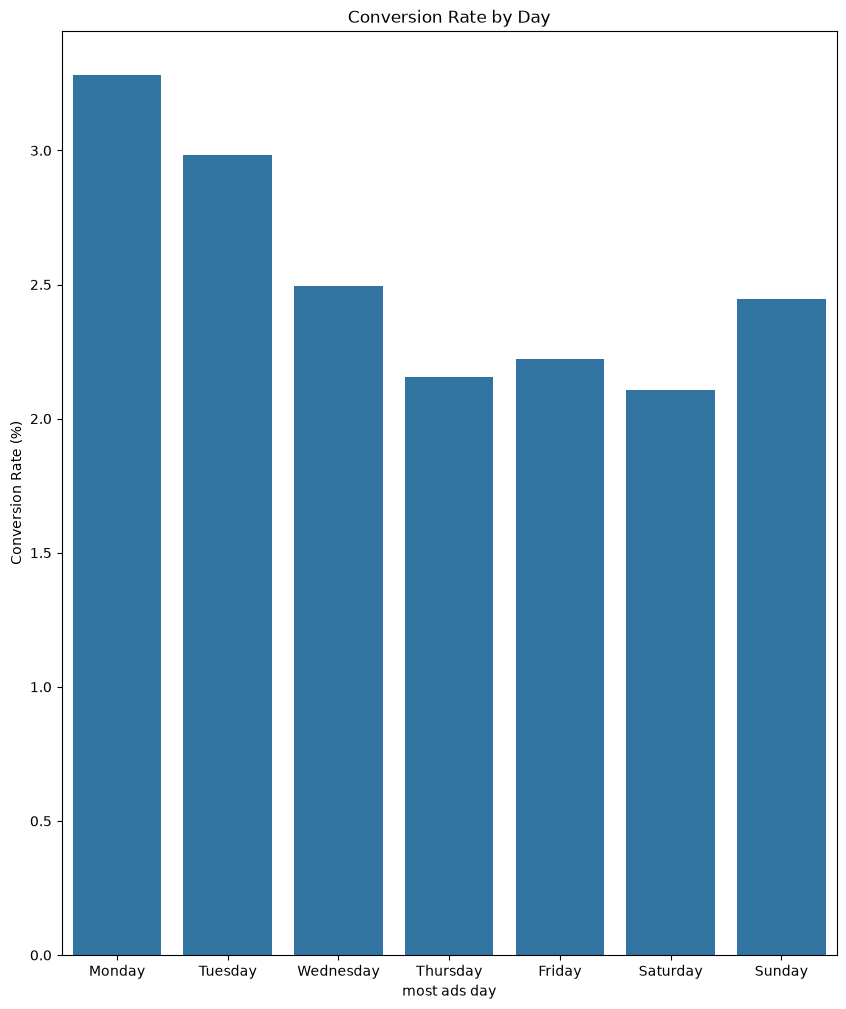

In [39]:
day_conversion_rate = df.groupby('most ads day')['converted'].mean()*100
map = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}

day_conversion_rate = day_conversion_rate.sort_index(key = lambda x: x.map(map))

print(day_conversion_rate)


plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = day_conversion_rate.index, y = day_conversion_rate.values)
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Day")

The results show some slight variations in conversion rates between different days of the week. The highest results are when advertisements are most viewed on `Monday` with a conversion rate of `3.28%`, followed by `Tuesday` with the second highest conversion rate at `2.98%`. There is a continuous downward trend in conversion rates up to `Thursday`, which has a conversion rate of `2.16%`. The day with the lowest conversion rate is Saturday at `2.11%`. `Sunday` increases the conversion rate to `2.44%`. 

Although the results suggest there may be an association between consumer behaviour and the day of the week, it's important to note that these fluctuations are very small when compared to the differences in conversion rate by number of ads seen, thus making the day of the week a relatively weak indicator of conversion rate. This analysis therefore provides some context, but does not provide evidence that the day of the week is itself an indicator of conversion.

### Conversion Rate By Hour

The final analysis will investigate whether there is an association between the hour of the day that the most ads are seen and the conversion rate. Understanding this could provide additional insight into the time of day that advertisements are the most effective. 

I will calculate the conversion rate for each hour (`0-23`) and plot the results in a bar chart. This will allow any notable differences in the rate of conversion throughout the day to be identified. 

most ads hour
0     1.842486
1     1.291129
2     0.731296
3     1.045166
4     1.523546
5     2.091503
6     2.224371
7     1.811085
8     1.951552
9     1.919107
10    2.152084
11    2.211643
12    2.382765
13    2.467737
14    2.806257
15    2.965334
16    3.077169
17    2.820967
18    2.737988
19    2.671982
20    2.980327
21    2.892314
22    2.610472
23    2.266191
Name: converted, dtype: float64


Text(0.5, 1.0, 'Conversion Rate by Hour')

<Figure size 640x480 with 0 Axes>

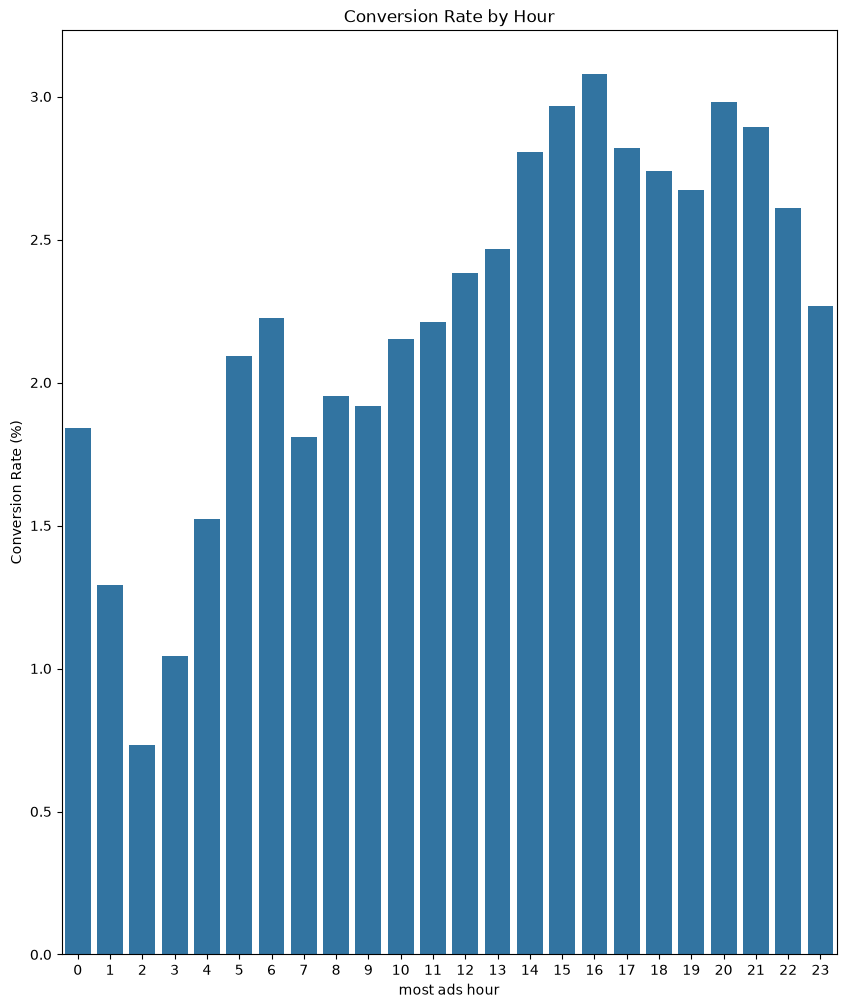

In [40]:
hour_conversion_rate = df.groupby('most ads hour')['converted'].mean()*100
print(hour_conversion_rate)


plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = hour_conversion_rate.index, y = hour_conversion_rate.values)
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Hour")

The results show that there is indeed an association between the hour of the day that the most ads are viewed and the conversion rate. Conversion was lowest during the early hours, reaching a low of `0.73%` at `02:00`, then generally increasing throughout the day. The highest rate of conversion was at `16:00` at `3.08%`, with conversion rates staying relatively high until `23:00` at which point they decreased throughout the night. 

These results indicate that there is indeed an association between the time of day that a users view the most advertisements and their likelihood of converting. However, as with the previous analyses this is an observational relationship and does not indicate that there is statistical significance in the difference of conversion rates. These results do however provide additional context as to when users are most likely to convert and can be used when considering the time of day in which marketing is focussed. 

## <u>Limitations, Assumptions and Conclusions</u>

### Limitations and Assumptions

Although the hypothesis test gives strong evidence of statistical significance, there are several limitations that should be kept in mind when interpreting the results. 

<u>**Imbalance in treatment and control groups**</u>\
The `treatment` and `control` groups are very imbalanced, with the `treatment` group consisting of `96%` percent of the dataset and the `control` group only `4%`. While the sample size of the treatment group is large enough to satisfy central limit theorem, the dataset does not provide information as to why the groups are so imbalanced or how they were allocated. Therefore random assignment cannot be verified with complete certainty. 

<u>**Causal Interpretation**</u>\
While the A/B test does provide statistical evidence of conversion rates between the two groups, the strength of the causality is dependent on the experimental design. If the users were not truly randomly designed, potential confounders found in the differences between the control and treatment groups could also contribute to difference in conversion rate. \
The secondary analysis is also only observational. As an example, our analysis found that there was an association between the number of ads viewed and conversion rate. However, there are numerous potential confounding variables that cannot be dismissed without knowledge of the experimental design, such as those who are existing customers being more likely to view the advertisements. Therefore, the relationships observed in the secondary analysis cannot be used to draw any causality. 

<u>**Statistical vs Practical Significance**</u>\
Despite there being strong statistical significance from the z-test, there is a difference between statistical and practical significance. We calculated a `relative lift` of `43.1%`, but in absolute terms this is an increase from a conversion rate of `1.79%` for the control group to `2.55%` for the treatment group. Without knowing the size of the existing customer base or the costs of marketing it is difficult to draw conclusions as to whether the advertisement campaign is cost-effective. 



### Conclusion

The aim of this analysis was to determine whether the conversion rate of users was increased when being shown an advertisement as opposed to a public service announcement. 

The dataset showed that the `treatment group` had a conversion rate of `2.55%` compared to the `control group`, giving an absolute difference of `0.77%` and a relative lift of `43.1%` when comparing the treatment to the control group. The `two-proportion z-test` produced a p-value of `1.71 × 10⁻¹³`, providing strong statistical evidence of a difference between the two groups. The 95% confidence interval of the difference between the two groups had a lower bound of `0.60%` and an upper bound of `0.94%`, further supporting statistical significance given that the lower bound is above 0. 

The secondary analysis gave additional context to the effect of the treatment group, exploring relationships between the number of ads viewed, the day of the week and the hour of the day and their respective conversion rates. The strongest observational pattern was the number of ads that the user was exposed to, with conversion rates increasing significantly as the number of ads increased. 

Overall, the results find there to be significant statistical evidence of advertisements being the stronger performing option. The findings give clear statistical evidence of preferring advertisements over public service announcements, though the cost of the campaign in relation to the relative lift should be considered before making a practical decision, along with the limitations discussed above. 